### **1 Error**

#### 1.1 Training Error and Generalization Error

##### 1.1.1 Training error: the model's error on the training data

##### 1.1.2 Generalization error: the model's error on new data

---

#### 1.2 Validation Dataset and Test Dataset

##### 1.2.1 Validation dataset: a dataset used to evaluate how good a model is (do not mix it with the training data)

##### 1.2.2 Test dataset: a dataset that is used only once

---

#### 1.3 K-Fold Cross-Validation

* Used when there is not enough data
* Algorithm:
    * Split the training data into K folds
    * For i =1,2,...,K
        * Use the i-th fold as the validation dataset and the rest as the training dataset
    * Report the average of the K validation errors
* Common choices: K = 5 or 10

### **2 Overfitting and Underfitting**

#### 2.1 Table

| Model Capacity\Data | Simple | Complex |
| --- | --- | --- |
| Low | Normal | Underfitting |
| High | Overfitting | Normal |

---

#### 2.2 Model Capacity

* The ability to fit various functions
* Low-capacity models have difficulty fitting the training data
* High-capacity models can memorize all the training data

---

#### 2.3 Estimating Model Capacity

* It is difficult to compare across different types of algorithms
    * For example, tree models and neural networks
* Given a model type, there are two main factors
    * The number of parameters
    * The range of possible parameter values

---

#### 2.4 VC Dimension

* A core idea in statistical learning theory
* For a classification model, the VC dimension equals the size of the largest dataset such that, no matter how the labels are assigned, there exists a model that can classify it perfectly.

---

#### 2.5 VC Dimension of Linear Classifiers

* For a perceptron with 2-dimensional inputs, the VC dimension is 3
    * It can classify any 3 points
* The VC dimension of a perceptron with N-dimensional inputs is N+1
* The VC dimension of some multilayer perceptrons is O(Nlog2N)

---

#### 2.6 Uses of VC Dimension

* Provides a theoretical basis for why a model is good
    * It can measure the gap between training error and generalization error
* It is rarely used in deep learning
    * The measurement is inaccurate
    * It is difficult to compute the VC dimension of deep learning models

---

#### 2.7 Data Complexity

* Several important factors
    * The number of examples
    * The number of elements in each example
    * Temporal and spatial structure
    * Diversity


### **3 Code Implementation**

#### 3.1 Model Selection, Underfitting, and Overfitting

In [1]:
# Explore these concepts interactively through polynomial fitting
import math
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

Use the following third-degree polynomial to generate labels for the training and test data

$$
y = 5 + 1.2x - 3.4\frac{x^2}{2!} + 5.6\frac{x^3}{3!} + \epsilon \text{ where } \epsilon \sim \mathcal{N}(0, 0.1^2)
$$


In [2]:
max_degree = 20  # Maximum degree of the polynomial
n_train, n_test = 100, 100  # Sizes of the training and test datasets
true_w = np.zeros(max_degree)  # Allocate a large amount of space
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)  # gamma(n)=(n-1)!
# Shape of labels: (n_train+n_test,)
labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale=0.1, size=labels.shape)

In [3]:
# Look at the first 2 examples
true_w, features, poly_features, labels = [torch.tensor(x, dtype=
    torch.float32) for x in [true_w, features, poly_features, labels]]

features[:2], poly_features[:2, :], labels[:2]

(tensor([[0.1461],
         [0.6851]]),
 tensor([[1.0000e+00, 1.4607e-01, 1.0668e-02, 5.1944e-04, 1.8968e-05, 5.5415e-07,
          1.3491e-08, 2.8151e-10, 5.1400e-12, 8.3423e-14, 1.2186e-15, 1.6181e-17,
          1.9697e-19, 2.2132e-21, 2.3091e-23, 2.2486e-25, 2.0528e-27, 1.7639e-29,
          1.4314e-31, 1.1004e-33],
         [1.0000e+00, 6.8508e-01, 2.3467e-01, 5.3589e-02, 9.1782e-03, 1.2576e-03,
          1.4359e-04, 1.4053e-05, 1.2034e-06, 9.1604e-08, 6.2756e-09, 3.9085e-10,
          2.2313e-11, 1.1759e-12, 5.7541e-14, 2.6280e-15, 1.1253e-16, 4.5347e-18,
          1.7259e-19, 6.2231e-21]]),
 tensor([5.1705, 5.0987]))

In [4]:
# Implement a function to evaluate the model's loss on a given dataset
def evaluate_loss(net, data_iter, loss):  
    """Evaluate the model's loss on a given dataset"""
    metric = d2l.Accumulator(2)  # Sum of losses, number of examples
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())
    return metric[0] / metric[1]

In [5]:
# Define the training function
def train(train_features, test_features, train_labels, test_labels,
          num_epochs=400):
    loss = nn.MSELoss(reduction='none')
    input_shape = train_features.shape[-1]
    # Do not set a bias, because we have already implemented it in the polynomial features
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    batch_size = min(10, train_labels.shape[0])
    train_iter = d2l.load_array((train_features, train_labels.reshape(-1,1)),
                                batch_size)
    test_iter = d2l.load_array((test_features, test_labels.reshape(-1,1)),
                               batch_size, is_train=False)
    trainer = torch.optim.SGD(net.parameters(), lr=0.01)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log',
                            xlim=[1, num_epochs], ylim=[1e-3, 1e2],
                            legend=['train', 'test'])
    for epoch in range(num_epochs):
        d2l.train_epoch_ch3(net, train_iter, loss, trainer)
        if epoch == 0 or (epoch + 1) % 20 == 0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss),
                                     evaluate_loss(net, test_iter, loss)))
    print('weight:', net[0].weight.data.numpy())

weight: [[ 4.973588   1.2320498 -3.3043718  5.381781 ]]


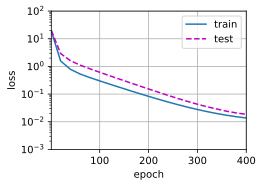

In [6]:
# Third-degree polynomial function fitting (normal)
train(poly_features[:n_train, :4], poly_features[n_train:, :4],
      labels[:n_train], labels[n_train:])

weight: [[3.7519295 2.47379  ]]


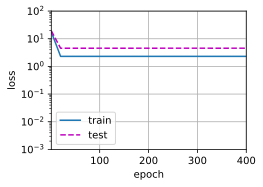

In [7]:
# Linear function fitting (underfitting)
# Select the first 2 dimensions from the polynomial features, namely 1 and x
train(poly_features[:n_train, :2], poly_features[n_train:, :2],
      labels[:n_train], labels[n_train:])

weight: [[ 5.0162497   1.1798236  -3.4377632   5.392444    0.08577144  1.0191137
   0.11404372  0.29491857 -0.11783072  0.1876681  -0.10847401  0.01698923
   0.04671358  0.015317   -0.07335979  0.22099046 -0.08267888  0.1790955
   0.10405172  0.12000596]]


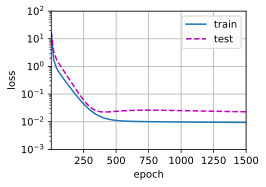

In [8]:
# Higher-degree polynomial function fitting (overfitting)
# Select all dimensions from the polynomial features
train(poly_features[:n_train, :], poly_features[n_train:, :],
      labels[:n_train], labels[n_train:], num_epochs=1500)

### **4 Weight Decay**

#### 4.1 Using the Squared Norm as a Hard Constraint

* Control model capacity by restricting the range of parameter values

$$
\min \ell(\mathbf{w}, b) \quad \text{subject to} \quad \|\mathbf{w}\|^2 \le \theta
$$

* Usually, the bias b is not constrained
* A smaller θ means a stronger regularization term

---

#### 4.2 Using the Squared Norm as a Soft Constraint

* For every θ, we can find a λ such that the previous objective function is equivalent to the following

$$
\min \ell(\mathbf{w}, b) + 1/2\|\mathbf{w}\|^2
$$

* This can be proved using Lagrange multipliers
* The hyperparameter λ controls the importance of the regularization term
    * λ = 0: no effect
    * λ -> ∞, w* -> 0

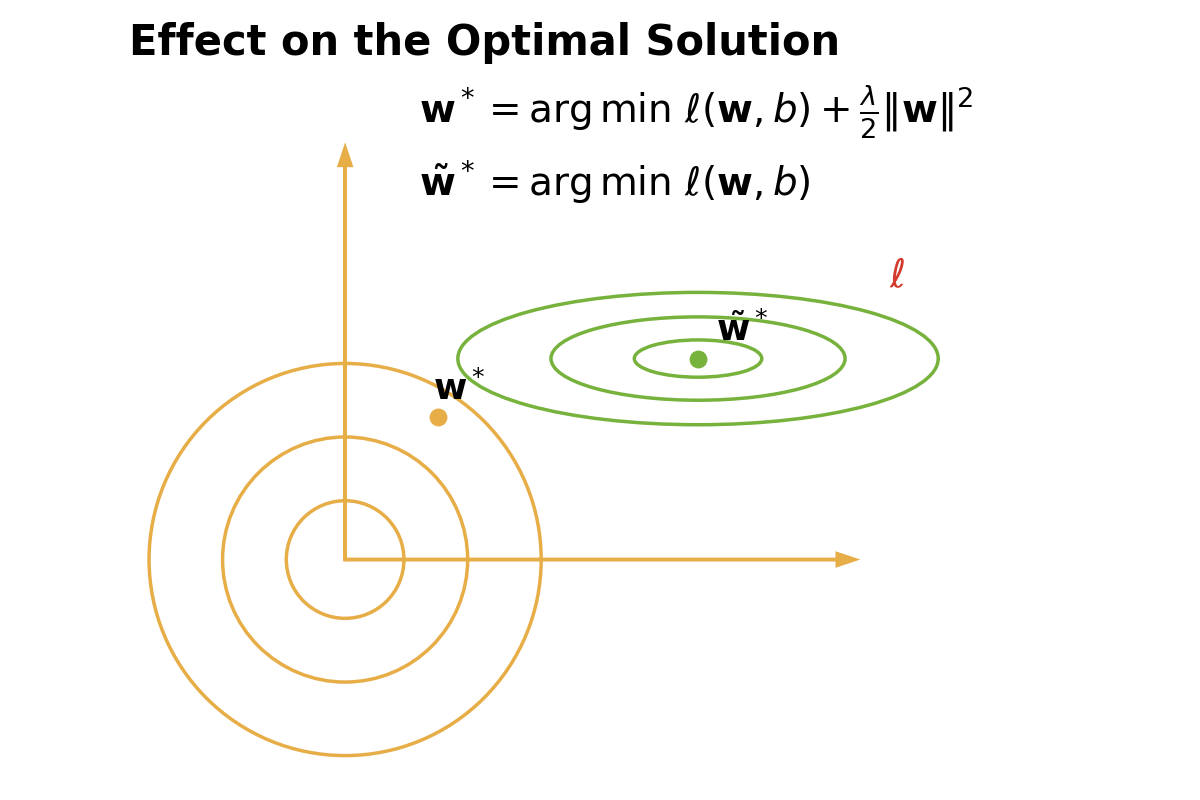

---

#### 4.3 Parameter Update Rule

* Compute the gradient

$$
\frac{\partial}{\partial \mathbf{w}} \left( \ell(\mathbf{w}, b) + \frac{\lambda}{2} \|\mathbf{w}\|^2 \right) = \frac{\partial \ell(\mathbf{w}, b)}{\partial \mathbf{w}} + \lambda \mathbf{w}
$$

* Update the parameters at time t

$$
\mathbf{w}_{t+1} = (1 - \eta\lambda)\mathbf{w}_t - \eta \frac{\partial \ell(\mathbf{w}_t, b_t)}{\partial \mathbf{w}_t}
$$

* Usually ηλ < 1; in deep learning, this is called weight decay

### **5 Code Implementation of Weight Decay**

Weight decay is one of the most widely used regularization techniques

#### 5.1 Start From Scratch

In [1]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

Generate some data as before

$$
y = 0.05 + \sum_{i=1}^{d} 0.01x_i + \epsilon \quad \text{where } \epsilon \sim \mathcal{N}(0, 0.01^2)
$$


In [2]:
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)

In [3]:
# Initialize model parameters
def init_params():
    w=torch.normal(0,1,size=(num_inputs,1),requires_grad=True)
    b=torch.zeros(1,requires_grad=True)
    return [w,b]


In [4]:
# Define the L2 norm penalty
def l2_penalty(w):
    return torch.sum(w.pow(2))/2

In [5]:
# Define the training code implementation
def train(lambd):
    w, b = init_params()
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss
    num_epochs, lr = 100, 0.003
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # Add the L2 norm penalty term,
            # broadcasting makes l2_penalty(w) a vector of length batch_size
            l = loss(net(X), y) + lambd * l2_penalty(w)
            l.sum().backward()
            d2l.sgd([w, b], lr, batch_size)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                     d2l.evaluate_loss(net, test_iter, loss)))
    print('The L2 norm of w is', torch.norm(w).item())

The L2 norm of w is 13.181363105773926


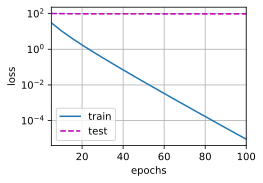

In [6]:
# Train directly while ignoring regularization
train(lambd=0)

The L2 norm of w is 0.36030417680740356


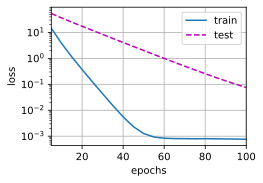

In [7]:
# Use weight decay
train(lambd=3)

#### 5.2 Simplefied Implementation

In [ ]:
# Concise implementation
def train_concise(wd):
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss(reduction='none')
    num_epochs, lr = 100, 0.003
    # The bias parameter is not decayed
    trainer = torch.optim.SGD([
        {"params":net[0].weight,'weight_decay': wd},
        {"params":net[0].bias}], lr=lr)
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.mean().backward()
            trainer.step()
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1,
                         (d2l.evaluate_loss(net, train_iter, loss),
                          d2l.evaluate_loss(net, test_iter, loss)))
    print('The L2 norm of w is:', net[0].weight.norm().item())

The L2 norm of w is: 12.919602394104004


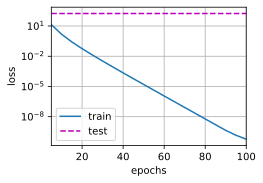

In [9]:
train_concise(0)

The L2 norm of w is: 0.5093926191329956


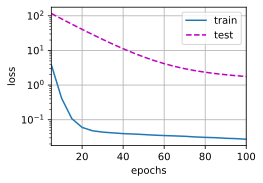

In [10]:
train_concise(3)

### **6 Dropout**

#### 6.1 Motivation

* A good model needs to be robust to perturbations in the input data
    * Using noisy data is equivalent to Tikhonov regularization
    * Dropout: add noise between layers

---

#### 6.2 Adding Noise Without Bias

* Add noise to x to obtain x'; we want E[xi'] = p·0 + (1-p)·xi/(1-p) = xi

$$
E[x'] = x
$$

* Dropout perturbs each element as follows

$$
x_i' = \begin{cases} 0 & \text{with probability } p \\ \frac{x_i}{1-p} & \text{otherwise} \end{cases}
$$

---

#### 6.3 Using Dropout

* Dropout is usually applied to the outputs of hidden fully connected layers

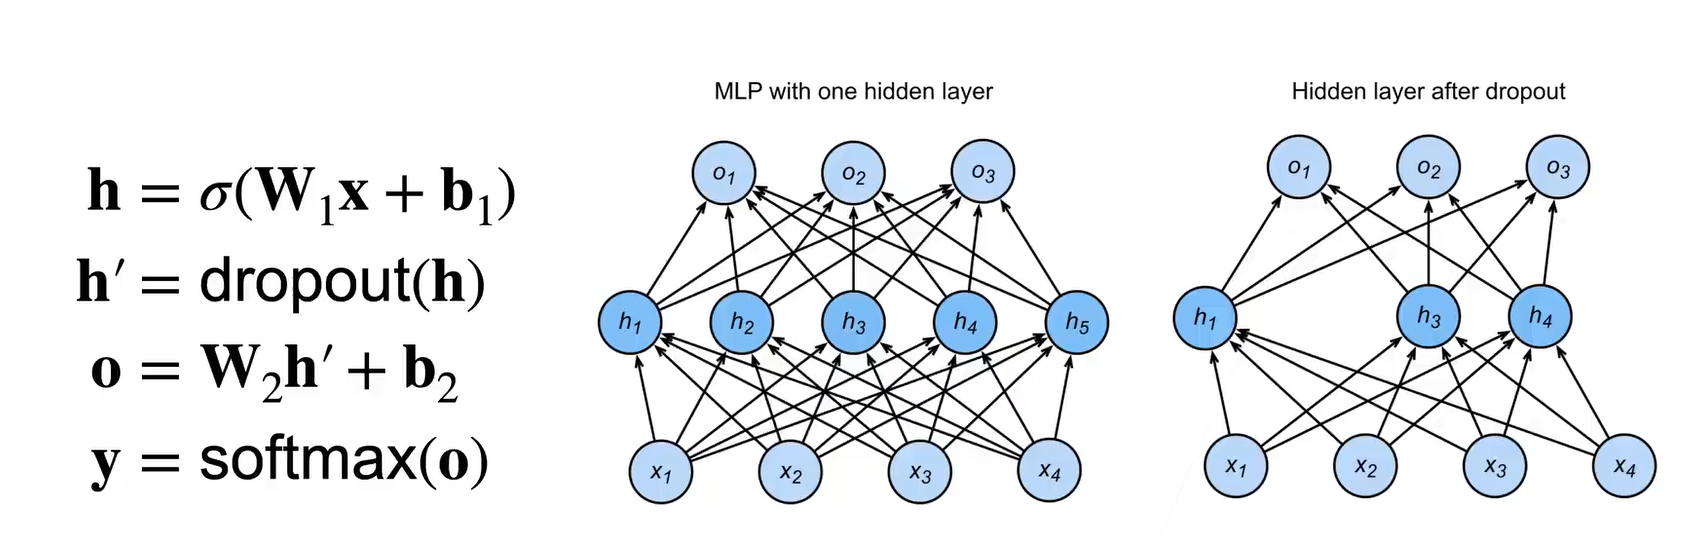

---

#### 6.4 Dropout During Inference

* Regularization terms are used only during training: they affect model parameter updates
* During inference, dropout directly returns the input

$$
h=dropout(h)
$$

* This also guarantees deterministic output

### **7 Implementation of Dropout**

#### 7.1 Start From Scratch

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
# The dropout_layer function drops elements in the tensor input X with probability dropout
def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1
    # In this case, all elements are dropped
    if dropout == 1:
        return torch.zeros_like(X)
    # In this case, all elements are kept
    if dropout == 0:
        return X
    mask = (torch.randn(X.shape) > dropout).float()
    return mask * X / (1.0 - dropout)

In [3]:
# Test dropout probabilities of 0, 0.5, and 1
X= torch.arange(16, dtype = torch.float32).reshape((2, 8))
print(X)
print(dropout_layer(X, 0.))
print(dropout_layer(X, 0.5))
print(dropout_layer(X, 1.))

tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  0.,  0.,  6.,  8.,  0.,  0., 14.],
        [ 0.,  0.,  0., 22.,  0., 26., 28.,  0.]])
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


In [ ]:
# Define an MLP with two hidden layers, each containing 256 units
num_inputs, num_outputs, num_hiddens1, num_hiddens2 = 784, 10, 256, 256

In [5]:
# Define the model
dropout1, dropout2 = 0.2, 0.5

class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens1, num_hiddens2,
                 is_training = True):
        super(Net, self).__init__()
        self.num_inputs = num_inputs
        self.training = is_training
        self.lin1 = nn.Linear(num_inputs, num_hiddens1)
        self.lin2 = nn.Linear(num_hiddens1, num_hiddens2)
        self.lin3 = nn.Linear(num_hiddens2, num_outputs)
        self.relu = nn.ReLU()

    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape((-1, self.num_inputs))))
        # Use dropout only when training the model
        if self.training == True:
            # Add a dropout layer after the first fully connected layer
            H1 = dropout_layer(H1, dropout1)
        H2 = self.relu(self.lin2(H1))
        if self.training == True:
            # Add a dropout layer after the second fully connected layer
            H2 = dropout_layer(H2, dropout2)
        out = self.lin3(H2)
        return out


net = Net(num_inputs, num_outputs, num_hiddens1, num_hiddens2)

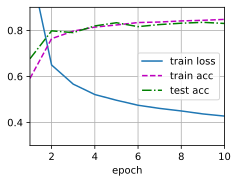

In [6]:
# Training and testing
num_epochs, lr, batch_size = 10, 0.5, 256
loss = nn.CrossEntropyLoss(reduction='none')
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
trainer = torch.optim.SGD(net.parameters(), lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

#### 7.2 Simplified Implementation

In [7]:
net = nn.Sequential(nn.Flatten(),
        nn.Linear(784, 256),
        nn.ReLU(),
        # Add a dropout layer after the first fully connected layer
        nn.Dropout(dropout1),
        nn.Linear(256, 256),
        nn.ReLU(),
        # Add a dropout layer after the second fully connected layer
        nn.Dropout(dropout2),
        nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights);

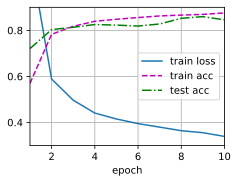

In [8]:
# Train and test
trainer = torch.optim.SGD(net.parameters(), lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)